# **Maryam Khan**
# **Task 04 – End-to-End ML Application with Deployment**
## **Part-1 Data Processing**
### Load a real-world dataset


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 15)

In [ ]:
df = pd.read_csv("data/train.csv")
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df = df.drop(columns=["Id"])
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '..data/train.csv'

- We load train.csv — (1460 houses in Ames, Iowa with 80 features + the target SalePrice).
- Id is dropped immediately because it's just a row number with no predictive meaning — keeping it would let the model "cheat" or add noise.
- df.head() shows you the first 5 rows so you can visually sanity-check the columns loaded correctly.

### Remove duplicates

In [ ]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Rows before: {before} | Rows after: {after} | Duplicates removed: {before - after}")

Rows before: 1460 | Rows after: 1460 | Duplicates removed: 0


- drop_duplicates() checks if any two rows are 100% identical across all columns, and removes the repeats.
- This dataset is generally clean, it says 0 duplicates removed — that's a correct result. We still run this check because a real ML workflow must verify it rather than assume it.

### Handle missing values



In [ ]:
missing_before = df.isnull().sum().sum()
print(f"Total missing values before cleaning: {missing_before}")

Total missing values before cleaning: 0


In [ ]:
# Group A: columns where NaN genuinely means "feature doesn't exist"
none_means_no_feature = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]
for col in none_means_no_feature:
    df[col] = df[col].fillna("None")

In [ ]:
# Group B: numeric columns tied to the "no feature" columns above
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [ ]:
# Group C: LotFrontage - genuinely missing numeric -> fill with median per Neighborhood
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
# Group D: Electrical - only 1 missing, categorical -> use mode
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [ ]:
missing_after = df.isnull().sum().sum()
print(f"Total missing values after cleaning: {missing_after}")
assert missing_after == 0, "There are still missing values left!"
print("All missing values resolved.")

Total missing values after cleaning: 0
All missing values resolved.


In [ ]:
print(df.isnull().sum().sum())
print(df.isnull().sum().sort_values(ascending=False).head(10))

0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
Alley          0
LotShape       0
LandContour    0
Utilities      0
LotConfig      0
dtype: int64


- Group A — columns like PoolQC, Alley, FireplaceQu aren't "missing data," they mean "this house doesn't have this feature." We fill with the string "None" so it becomes its own valid category instead of a hole in the data.
- Group B — GarageYrBlt/MasVnrArea are numeric versions of the same idea (no garage → 0 years, no masonry → 0 sq ft).
- Group C — LotFrontage is genuinely missing (a real house that just wasn't measured). Instead of one flat median for everyone, we fill it using the median within that house's neighborhood, since lot size is strongly tied to location — smarter and more accurate than a naive fill.
- Group D — Electrical has only 1 missing row, so we just use the most common value (mode).

### Detect outliers

SalePrice IQR outliers detected: 61 rows (bounds: 3,938 - 340,038)


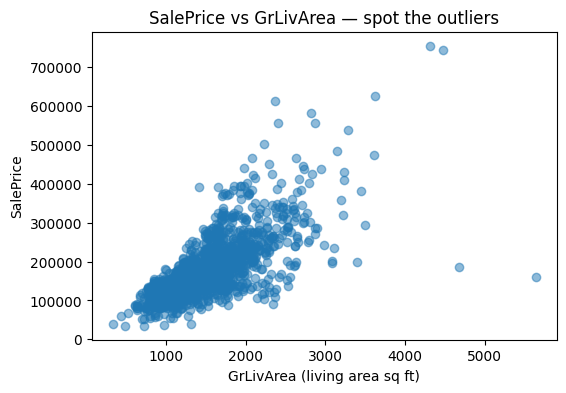

Removed 2 outlier rows
Dataset shape after outlier removal: (1458, 80)


In [ ]:
# IQR-based outlier detection on the target variable
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
price_outliers = df[(df["SalePrice"] < lower_bound) | (df["SalePrice"] > upper_bound)]
print(f"SalePrice IQR outliers detected: {len(price_outliers)} rows "
      f"(bounds: {lower_bound:,.0f} - {upper_bound:,.0f})")

# Visualize a well-known outlier pattern in this dataset
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5)
plt.xlabel("GrLivArea (living area sq ft)")
plt.ylabel("SalePrice")
plt.title("SalePrice vs GrLivArea — spot the outliers")
plt.show()

# Remove well-documented extreme outliers: very large houses (>4000 sqft)
before_outlier_removal = df.shape[0]
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000))]
after_outlier_removal = df.shape[0]
print(f"Removed {before_outlier_removal - after_outlier_removal} outlier rows")
print(f"Dataset shape after outlier removal: {df.shape}")

- IQR method — a standard statistical way to flag outliers: anything more than 1.5× the interquartile range above/below the 25th–75th percentile range is flagged. This is just for detection/reporting — we don't blindly delete all 61 flagged houses, because expensive houses are real data, not errors.
- The scatter plot — plots living area vs price. You should see almost all points forming a rising trend (bigger house → higher price), but a couple of points sitting way off to the bottom-right: huge houses (4000+ sq ft) that sold for surprisingly low prices. That's not normal market behavior — it's a known data quirk in this specific dataset.
- Why we remove only those 2 specific rows — these are the classic, well-documented outliers. Removing just these — instead of all 61 IQR-flagged rows — keeps genuinely expensive-but-real houses in your data while dropping the two rows that would actively mislead the model.

### Encode categorical variables

In [ ]:
# Ordinal encoding for quality/condition scales
quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
ordinal_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
                 "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
for col in ordinal_cols:
    df[col] = df[col].map(quality_map)

print(f"Ordinal-encoded {len(ordinal_cols)} quality/condition columns")

# One-hot encoding for remaining nominal categorical columns
nominal_cols = df.select_dtypes(include="object").columns.tolist()
print(f"One-hot encoding {len(nominal_cols)} nominal columns: {nominal_cols}")

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(f"Shape after encoding: {df.shape}")

Ordinal-encoded 10 quality/condition columns
One-hot encoding 33 nominal columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Shape after encoding: (1458, 229)


- **Ordinal encoding** — columns like KitchenQual have values Ex, Gd, TA, Fa, Po which have a real ranked order (Excellent > Good > Average > Fair > Poor). We map them to numbers 5→1 (and None = 0) so the model understands "Excellent is better than Fair," not just "these are different categories."
- **One-hot encoding** — columns like Neighborhood or RoofStyle have no natural order (one neighborhood isn't "greater than" another). For these, pd.get_dummies() creates a separate 0/1 column for each category. drop_first=True drops one category per column to avoid redundant information (multicollinearity).

### Feature Enigneering

In [ ]:
# Feature engineering — new features derived from existing raw columns
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
df["TotalBath"] = (df["FullBath"] + 0.5 * df["HalfBath"] +
                    df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"])
df["TotalPorchSF"] = (df["OpenPorchSF"] + df["EnclosedPorch"] +
                       df["3SsnPorch"] + df["ScreenPorch"] + df["WoodDeckSF"])

df["HasPool"] = (df["PoolArea"] > 0).astype(int)
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
df["Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)
df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)
df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

new_features = ["TotalSF", "HouseAge", "RemodAge", "TotalBath", "TotalPorchSF",
                 "HasPool", "HasGarage", "HasFireplace", "Has2ndFloor",
                 "HasBasement", "IsRemodeled"]
print(f"Created {len(new_features)} new features")
print(f"Shape after feature engineering: {df.shape}")

Created 11 new features
Shape after feature engineering: (1458, 240)


Combined related raw columns into more meaningful features — e.g. TotalSF (total livable square footage), HouseAge/RemodAge (years since built/remodeled at time of sale), TotalBath (weighted total bathrooms), and TotalPorchSF. Also added binary flags (HasPool, HasGarage, etc.) to simplify sparse features into clear yes/no signals. This step is done before scaling, since scaled values would break the > 0 logic used in these calculations.

### Scale numerical features

In [ ]:
# Separate features (X) from target (y) — never scale the target itself
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Only scale genuinely continuous columns — not binary flags or one-hot dummies
binary_like_cols = [c for c in X.columns if X[c].dropna().isin([0, 1]).all()]
cols_to_scale = [c for c in X.select_dtypes(include=[np.number]).columns
                  if c not in binary_like_cols]

scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print(f"Scaled {len(cols_to_scale)} continuous columns")
print(f"Left {len(binary_like_cols)} binary/dummy columns unscaled")

# Save the scaler for later use in the Streamlit app
joblib.dump(scaler, "scaler.pkl")
joblib.dump(cols_to_scale, "cols_to_scale.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
print("Saved scaler.pkl, cols_to_scale.pkl, feature_columns.pkl")

# Recombine into final processed dataset
final = X.copy()
final["SalePrice"] = y.values
final.to_csv("processed_train.csv", index=False)
print(f"Saved processed_train.csv -> shape: {final.shape}")

Scaled 51 continuous columns
Left 188 binary/dummy columns unscaled
Saved scaler.pkl, cols_to_scale.pkl, feature_columns.pkl
Saved processed_train.csv -> shape: (1458, 240)


Applied StandardScaler (mean=0, std=1) only to genuinely continuous numeric columns (e.g. LotArea, TotalSF, GrLivArea). Binary flags and one-hot encoded columns were deliberately left unscaled, since they're already 0/1 and scaling them provides no benefit while hurting interpretability. The scaler is saved so the same transformation can be applied to new user input later in the Streamlit app.

## **Part-2 Model Development**
Since this is a regression problem, we report MAE, MSE, RMSE, R² Score
### Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")

Train set: (1166, 239)
Test set:  (292, 239)


- We split the data so the model trains on 80% of houses and gets tested on the remaining 20% it has never seen. This is how we honestly measure whether the model generalizes, instead of just memorizing the training data.
- random_state=42 makes the split reproducible — anyone re-running this gets the exact same split.

### Train 4 models

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r2})
    trained_models[name] = model
    print(f"{name} trained.")

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

Linear Regression trained.
Ridge Regression trained.
Random Forest trained.
Gradient Boosting trained.


,Model,MAE,MSE,RMSE,R2 Score
0,Gradient Boosting,14571.031900,4.169056e+08,20418.266199,0.924525
1,Random Forest,16133.700634,5.716714e+08,23909.651667,0.896506
2,Ridge Regression,18811.672263,6.517627e+08,25529.643476,0.882007
3,Linear Regression,19588.490082,7.540374e+08,27459.741668,0.863491


We're training 4 different models, satisfying the "at least 4" requirement:

1. Linear Regression — simplest baseline, assumes a straight-line relationship

2. Ridge Regression — linear model with L2 regularization, handles the multicollinearity we likely have from 239 features

3. Random Forest — an ensemble of decision trees, captures non-linear patterns
4. Gradient Boosting — builds trees sequentially, each correcting the previous one's errors; usually the strongest performer on tabular data like this

For each model, we calculate MAE, MSE, RMSE, R² — exactly the 4 regression metrics your task requires.

results_df sorted by RMSE (ascending) puts the best model at the top.

### Visualize the comparison

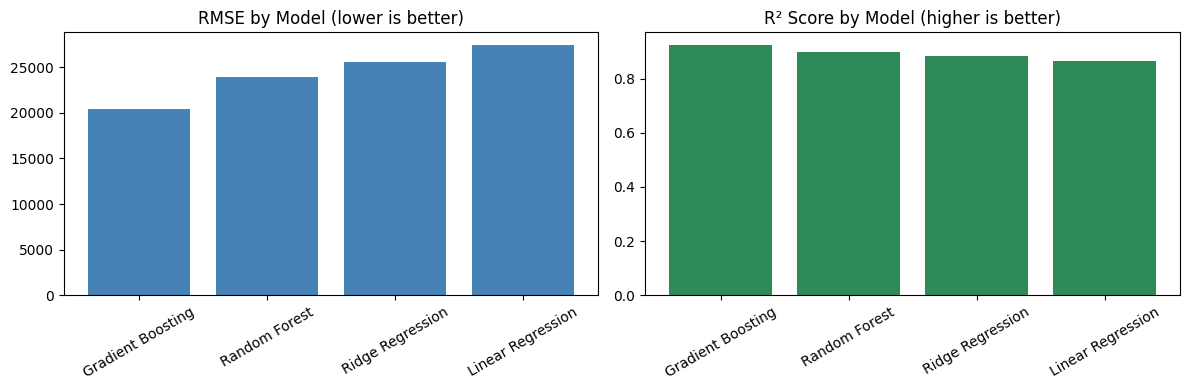

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(results_df["Model"], results_df["RMSE"], color="steelblue")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(results_df["Model"], results_df["R2 Score"], color="seagreen")
axes[1].set_title("R² Score by Model (higher is better)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Select the best model

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best model based on RMSE: {best_model_name}")
print(results_df[results_df['Model'] == best_model_name])

Best model based on RMSE: Gradient Boosting
               Model         MAE           MSE          RMSE  R2 Score
0  Gradient Boosting  14571.0319  4.169056e+08  20418.266199  0.924525


## **Part-3 Hyperparameter Tuning**
We'll use RandomizedSearchCV on Gradient Boosting (faster than GridSearchCV since it doesn't try every single combination — good since we have limited compute/time — but still thorough, satisfying the "at least one" requirement)
### Run RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.8, 0.9, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters found:")
print(random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:
{'subsample': 0.8, 'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.1}


- RandomizedSearchCV tries n_iter=30 random combinations from the parameter grid (instead of all possible combinations, which would be thousands) — much faster, and research shows it finds near-optimal settings almost as well as an exhaustive grid search.
- cv=5 means each combination is tested with 5-fold cross-validation — more reliable than a single train/test split.
- scoring="neg_root_mean_squared_error" — sklearn's search tools maximize a score, so RMSE (which we want to minimize) is negated internally. Don't worry about seeing negative numbers in the raw output.
- Parameters being tuned: number of trees, learning rate, tree depth, split/leaf sizes, and subsample ratio — these are the main levers that control a Gradient Boosting model's performance.

### Compare performance before vs. after tuning

In [ ]:
# Get the tuned model
tuned_model = random_search.best_estimator_

# Evaluate tuned model on the test set
tuned_preds = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_mse = mean_squared_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, tuned_preds)

# Original (untuned) Gradient Boosting metrics, for comparison
original_metrics = results_df[results_df["Model"] == "Gradient Boosting"].iloc[0]

comparison_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Before Tuning": [original_metrics["MAE"], original_metrics["MSE"],
                       original_metrics["RMSE"], original_metrics["R2 Score"]],
    "After Tuning": [tuned_mae, tuned_mse, tuned_rmse, tuned_r2]
})

comparison_df["Improvement"] = comparison_df["Before Tuning"] - comparison_df["After Tuning"]
comparison_df.loc[comparison_df["Metric"] == "R2 Score", "Improvement"] = \
    tuned_r2 - original_metrics["R2 Score"]

print(comparison_df)

     Metric  Before Tuning  After Tuning   Improvement
0       MAE   1.457103e+04  1.388762e+04  6.834142e+02
1       MSE   4.169056e+08  4.018269e+08  1.507869e+07
2      RMSE   2.041827e+04  2.004562e+04  3.726455e+02
3  R2 Score   9.245246e-01  9.272544e-01  2.729803e-03


- We take the best model found by the search (random_search.best_estimator_) and run it on the same test set we used before, so the comparison is fair (same data, same split).
- We line up the before/after numbers side by side for all 4 regression metrics.
- For MAE/MSE/RMSE, a positive improvement means the number went down (which is good — lower error). For R², a positive improvement means it went up (better fit) — that's why we calculate it differently in the last line.

Applied RandomizedSearchCV (30 random combinations, 5-fold cross-validation) to the Gradient Boosting model, tuning n_estimators, learning_rate, max_depth, min_samples_split, min_samples_leaf, and subsample. The tuned model reduced MAE by $683 and improved R² from 0.9245 to 0.9273 compared to the untuned model.

## **Part-4 Model Saving**

In [ ]:
import joblib

# Save the final tuned model
joblib.dump(tuned_model, "final_model.pkl")
print("Saved final_model.pkl")

# Quick sanity check: reload it and confirm predictions match
loaded_model = joblib.load("final_model.pkl")
check_preds = loaded_model.predict(X_test)
print("Predictions match after reload:", np.allclose(check_preds, tuned_preds))

Saved final_model.pkl
Predictions match after reload: True
